# 05 · Two primitives, every cache

*Everything above the backends is plain Python and NumPy. A backend has to do exactly two things: run tokens on top of a cached prefix, and score rows against it. This post opens up what that takes: KV caches that must be copied without being touched, rows of different lengths, memory, a faster head, four cache designs and two frameworks.*

> **TL;DR**
> - A backend implements two methods: `prefill` extends a cached prefix, `score` reads log-probabilities from rows appended to one. A fresh 28-field request is five calls and five forward passes, counted by the backend as they happen.
> - A prefix is the framework's own KV cache, one object per layer. Copying it to 27 rows is free until the rows write into it; then every row holds a full copy. Memory, not arithmetic, sets the batch size, and `kv_budget_bytes` trades one for the other: a quarter of the peak memory for about 1.3× the decode time.
> - Rows never leak into each other, but they are not bit-exact: in fp16 the shape of the batch moves a row's distribution by a total-variation distance of up to ~1e-2, never enough to change a decision here, and float32 shrinks it more than 500-fold. Continuing a padded batch, which `pcd` never does, would be a real bug: it changes most next tokens.
> - The same copy routine handles plain, sliding-window, linear-attention and convolution caches; all four architectures pass the conformance suite, and the same bf16 checkpoint gives the same decisions on MLX and PyTorch for 86 of 88 fields (88 of 88 in float32). On the way we found that Qwen3.5 runs without the fast path unless its head is registered.

Posts [02](02_schemas_and_prompts.ipynb) to [04](04_decoding.ipynb) built prompts, compiled rows and read decisions without ever touching a model directly. They all go through `backends/`, the only code in `pcd` that imports MLX or PyTorch. We start with Qwen2.5-1.5B-Instruct (4-bit MLX), then load other architectures one at a time, and finish with the same checkpoint on MLX and on PyTorch.

In [1]:
from nbutils import *
import copy
import dataclasses
import sys
import tempfile
from collections import Counter
from contextlib import contextmanager
from dataclasses import replace

import numpy as np
import mlx.core as mx
import matplotlib.pyplot as plt
from mlx.utils import tree_flatten

from pcd import Engine
from pcd.backends.base import Query, pad_rows, verify_close
from pcd.backends.mlx_backend import MLXBackend, _default_split, _HEAD_REGISTRY, register_head
from pcd.compiler import encode_after
from pcd.decoding import decode_fields
from pcd.models import MODELS
from pcd.testing import check_backend

environment()
engine = Engine(load())          # qwen2.5-1.5b, 4-bit MLX
backend, tok = engine.backend, engine.tokenizer
VOCAB = tuple(range(tok.vocab_size))
preset = load_preset("support_triage")
ticket, schema = preset["context"], preset["schema"]
cs = engine.compile(schema)
out = engine.extract(ticket, schema)
names = cs.schema.names[1:]                        # the 27 fields of the batched round
rows = [cs.fields[n].prefix for n in names]


def engine_prefixes(cs, context, first_value):
    """The two KV states the engine decides against: the prompt (head, then context), and the
    prompt followed by the first field's answer line (post 06 explains the anchor)."""
    ids = tok.encode(cs.prompt.render(context.strip()))
    head = backend.prefill(cs.head_ids)
    p0 = backend.prefill(ids[len(cs.head_ids):], parent=head)
    first = cs.schema.names[0]
    line = encode_after(tok, cs.prompt.tail, cs.answer_text({first: first_value}))
    return p0, backend.prefill(line, parent=p0)


def tv(a, b):
    """Total-variation distance between two full-vocabulary log-prob vectors."""
    return 0.5 * float(np.abs(np.exp(a) - np.exp(b)).sum())


@contextmanager
def float32(model):
    """Run an MLX model with float32 activations, then put the original parameters back."""
    saved = model.parameters()
    model.set_dtype(mx.float32)
    try:
        yield
    finally:
        model.update(saved)


first_value = out.values[cs.schema.names[0]]
p0, p1 = engine_prefixes(cs, ticket, first_value)
print(f"prompt {len(p0)} tokens; with the first answer line {len(p1)} tokens; batched round: {len(rows)} rows")

Apple M1 Pro, 16 GB | macOS 15.1.1 | Python 3.13.5 | pcd 0.1.0, mlx 0.32.2, mlx-lm 0.31.3, torch 2.14.0, transformers 5.17.0
prompt 1146 tokens; with the first answer line 1155 tokens; batched round: 27 rows


## 1. The contract

The whole interface is in the docstring of `backends/base.py`:

In [2]:
show_source("backends/base.py", "``prefill(tokens, parent=None)", "predicts the token at")

# src/pcd/backends/base.py
 7  ``prefill(tokens, parent=None) -> Prefix``
 8      Run ``tokens`` through the model on top of ``parent``'s KV state (or from scratch)
 9      and return a new, immutable prefix. Must not modify ``parent``.
10  
11  ``score(prefix, rows, queries) -> list[np.ndarray]``
12      Treat every row as a continuation of ``prefix`` (all rows share the prefix's KV
13      state, broadcast to the batch). For each query ``(row, position, token_ids)`` return
14      the full-vocabulary log-softmax, at that position of that row, of the requested
15      token ids. ``position`` indexes into the row; the distribution at position ``p``
16      predicts the token at ``p + 1``. Must not modify ``prefix``.


Why only two? Because everything the engine does is one of them. Extending a prompt (the context on top of a cached head, the answer lines between waves) is a `prefill` on a parent. Every decoder in post [04](04_decoding.ipynb), from first-token scoring to the 255-label trie, is a `score` call: rows appended to a prefix, and queries that ask for a few log-probabilities at one position of one row.

We can watch the engine from the backend's side by wrapping the two methods and recording every call:

In [3]:
class CallLog:
    """Record every prefill / score call made inside the block, with the forward passes it cost."""

    def __init__(self, backend):
        self.backend, self.calls = backend, []

    def __enter__(self):
        b = self.backend

        def wrap(name):
            method = getattr(type(b), name)

            def call(*args, **kwargs):
                before = b.forward_passes
                result = method(b, *args, **kwargs)
                self.calls.append((name, args, kwargs, result, b.forward_passes - before))
                return result

            return call

        b.prefill, b.score = wrap("prefill"), wrap("score")
        return self

    def __exit__(self, *exc):
        del self.backend.prefill, self.backend.score

    def table(self):
        out = []
        for i, (name, args, kwargs, result, passes) in enumerate(self.calls, 1):
            if name == "prefill":
                parent = kwargs.get("parent", args[1] if len(args) > 1 else None)
                where = f"on a {len(parent)}-token parent" if parent is not None else "from scratch"
                out.append([i, "`prefill`", f"{len(args[0])} tokens {where}", f"a {len(result)}-token prefix", passes])
            else:
                prefix, rws, queries = args
                out.append([i, "`score`", f"{len(rws)} row(s), {len(queries)} queries, on {len(prefix)} tokens",
                            f"{sum(len(q.tokens) for q in queries)} log-probs", passes])
        md_table(["#", "call", "input", "output", "forward passes"], out)


fresh = Engine(backend)                  # a new engine: nothing cached yet
with CallLog(backend) as cold:
    fresh.extract(ticket, schema)
cold.table()
with CallLog(backend) as warm:
    again = fresh.extract(ticket, schema)
print(f"second request: {len(warm.calls)} calls ({', '.join(c[0] for c in warm.calls)}), "
      f"{sum(c[4] for c in warm.calls)} forward passes; Stats.forward_passes = {again.stats.forward_passes}")

| # | call | input | output | forward passes |
|---|---|---|---|---|
| 1 | `prefill` | 901 tokens from scratch | a 901-token prefix | 1 |
| 2 | `prefill` | 245 tokens on a 901-token parent | a 1146-token prefix | 1 |
| 3 | `score` | 1 row(s), 1 queries, on 1146 tokens | 4 log-probs | 1 |
| 4 | `prefill` | 9 tokens on a 1146-token parent | a 1155-token prefix | 1 |
| 5 | `score` | 27 row(s), 46 queries, on 1155 tokens | 129 log-probs | 1 |

second request: 4 calls (prefill, score, prefill, score), 4 forward passes; Stats.forward_passes = 4


Five calls decide 28 fields on a fresh engine: the prompt head (instructions and catalog, post [02](02_schemas_and_prompts.ipynb)), the ticket on top of it, one row for the first field, its answer line, and one batched call for the other 27 fields. From the second request on, the head comes from the engine's cache and the first call disappears. The cache is nothing more than a reference to the first `Prefix`, which is safe only because nobody ever modifies one.

In [4]:
show_source("backends/base.py", "class Query", "return len(self.tokens)")
try:
    p1.tokens = p1.tokens[:10]
except dataclasses.FrozenInstanceError as e:
    print("\nFrozenInstanceError:", e)

# src/pcd/backends/base.py
39  class Query:
40      row: int
41      position: int
42      tokens: tuple[int, ...]
43  
44  
45  @dataclass(frozen=True, eq=False)
46  class Prefix:
47      """An immutable KV state for a token sequence."""
48  
49      tokens: tuple[int, ...]
50      #: Backend-specific cache object. Never mutate it.
51      state: Any = field(repr=False)
52      #: Bytes held by one copy of the state; used to size batches.
53      nbytes: int = 0
54  
55      def __len__(self) -> int:
56          return len(self.tokens)

FrozenInstanceError: cannot assign to field 'tokens'


`frozen=True` stops anyone from rebinding a field, but `state` is a list of cache objects that the framework updates in place when a model runs on them. The promise that `prefill` and `score` never modify their input is kept by the backend, not by Python. The next two sections show how.

## 2. What a prefix holds, and how it is copied

On MLX, `state` is mlx-lm's own prompt cache: one object per layer.

In [5]:
layer = p1.state[0]
print(f"{len(p1.state)} layers, each a {type(layer).__name__}")
for k, a in tree_flatten(layer.state):
    print(f"  state[{k}]  shape {tuple(a.shape)}  {a.dtype}")
print(f"  offset {layer.offset}; the buffer behind it is {tuple(layer.keys.shape)} (it grows {layer.step} tokens at a time)")

args = backend.model.args
head_dim = args.hidden_size // args.num_attention_heads
per_token = 2 * args.num_hidden_layers * args.num_key_value_heads * head_dim * 2
print(f"\nbytes per token = 2 (K and V) x {args.num_hidden_layers} layers x {args.num_key_value_heads} KV heads "
      f"(shared by {args.num_attention_heads} query heads) x {head_dim} dims x 2 bytes = {per_token:,}")
print(f"x {len(p1)} tokens = {per_token * len(p1) / 2**20:.2f} MiB;  Prefix.nbytes = {p1.nbytes / 2**20:.2f} MiB")

28 layers, each a KVCache
  state[0]  shape (1, 2, 1155, 128)  mlx.core.float16
  state[1]  shape (1, 2, 1155, 128)  mlx.core.float16
  offset 1155; the buffer behind it is (1, 2, 1402, 128) (it grows 256 tokens at a time)

bytes per token = 2 (K and V) x 28 layers x 2 KV heads (shared by 12 query heads) x 128 dims x 2 bytes = 28,672
x 1155 tokens = 31.58 MiB;  Prefix.nbytes = 31.58 MiB


Keys and values, batch 1, two KV heads (grouped-query attention keeps this small), one entry per token. To score 27 rows in one pass, every row needs its own copy of this state with the batch axis repeated, and the copy must not share anything the model will write into. This is the whole copy routine:

In [6]:
show_source(MLXBackend._clone)

# src/pcd/backends/mlx_backend.py
176      @staticmethod
177      def _clone(cache: list, n: int) -> list:
178          """Independent copy of a per-layer cache with its batch axis repeated ``n`` times."""
179  
180          def rep(a: Any) -> Any:
181              if a is None:
182                  return None
183              # mx.array(a) makes a new array object, so writes to the copy never reach `a`.
184              return mx.repeat(a, n, axis=0) if n > 1 else mx.array(a)
185  
186          return [type(c).from_state(tree_map(rep, c.state), c.meta_state) for c in cache]


It relies only on mlx-lm's generic `state` / `meta_state` / `from_state` protocol, so it does not care what kind of cache a layer has (section 6 puts that to the test). Here it is at work on the engine's batch:

In [7]:
before = [np.array(l.state[0]) for l in p1.state[:2]]       # layers 0 and 1, to compare afterwards
mx.synchronize(); mx.clear_cache()
base = mx.get_active_memory()
clone = MLXBackend._clone(p1.state, len(rows))
mx.eval([a for l in clone for a in l.state])
print(f"{len(rows)} copies of a {p1.nbytes / 2**20:.1f} MiB prefix: active memory +{(mx.get_active_memory() - base) / 2**20:.1f} MiB")

mx.reset_peak_memory()
backend.model(mx.array(pad_rows(rows, tok.pad_id)), cache=clone)
mx.eval([a for l in clone for a in l.state])
expected = len(rows) * clone[0].keys.shape[2] * per_token
print(f"after the rows are written: peak +{(mx.get_peak_memory() - base) / 2**20:.0f} MiB; clone buffer {tuple(clone[0].keys.shape)}, "
      f"offset {clone[0].offset}  ({len(rows)} x {clone[0].keys.shape[2]} tokens x {per_token:,} B = {expected / 2**20:.0f} MiB)")
print(f"parent: offset {p1.state[0].offset}, keys and values unchanged: "
      f"{all(np.array_equal(b, np.array(l.state[0])) for b, l in zip(before, p1.state[:2]))}")
del clone

27 copies of a 31.6 MiB prefix: active memory +0.0 MiB
after the rows are written: peak +1302 MiB; clone buffer (27, 2, 1411, 128), offset 1165  (27 x 1411 tokens x 28,672 B = 1042 MiB)
parent: offset 1155, keys and values unchanged: True


Two things to notice. `mx.repeat` does not copy anything: the 27 copies are a broadcast view, free until something is written. The first token a row writes makes the cache grow, and growing concatenates the view with a fresh block of 256 slots, so that is when 27 real copies appear. Each is sized to the prefix plus a whole allocation step, which is why a pass costs more than `27 × nbytes`. The parent is untouched: writes go to new arrays, and `mx.array(a)` in `_clone` makes sure even a single copy is a separate array object.

The PyTorch backend does the same with `transformers`' own cache API, and there the copy is real from the start:

In [8]:
show_source("backends/torch_backend.py", "def _broadcast", "return c")

# src/pcd/backends/torch_backend.py
169      def _broadcast(cache: Any, n: int) -> Any:
170          c = copy.deepcopy(cache)
171          if n > 1:
172              c.batch_repeat_interleave(n)
173          return c


## 3. Rows of different lengths

The 27 rows are between 5 and 10 tokens long. The backend right-pads them into one rectangle. That is safe by construction: under a causal mask a position never attends to anything after it, and every query reads a position inside its own row, before any padding.

What would not be safe is to keep going. Suppose a decoder, having read the first token of every row, appended the chosen token to each row of the same padded batch and ran one more step. For the shorter rows, the pad tokens now sit between the row and its new token, in the attention window and in the position count. We can simulate that and compare it with what `pcd` does, a new row scored against the untouched prefix:

In [9]:
longest = max(rows, key=len)
print(f"row lengths: {min(map(len, rows))} to {len(longest)} tokens")


def continued_after_padding(row, nxt):
    """What a backend that kept going after a padded batch would read: row, pads, then nxt."""
    cache = MLXBackend._clone(p1.state, 2)
    backend.model(mx.array([list(row) + [tok.pad_id] * (len(longest) - len(row)), list(longest)]), cache=cache)
    logits = backend.model(mx.array([[nxt], [nxt]]), cache=cache)[0, -1].astype(mx.float32)
    return np.array(logits - mx.logsumexp(logits), dtype=np.float64)[: len(VOCAB)]


cont = []
for n, row in zip(names, rows):
    if len(row) == len(longest):
        continue
    cf = cs.fields[n]
    nxt = next(v for v in cf.variants if cf.labels[v.label] == out.values[n]).seq[0]    # the answer's first token
    good = backend.score(p1, [tuple(row) + (nxt,)], [Query(0, len(row), VOCAB)])[0]
    bad = continued_after_padding(row, nxt)
    cont.append((tv(good, bad), n, len(longest) - len(row), nxt, good, bad))
cont.sort(key=lambda r: -r[0])
md_table(["field", "pads in between", "after", "clean row: next token", "after the pads: next token", "TV distance"],
         [[n, k, f"`{vis(tok.decode([nxt]))}`", f"`{vis(tok.decode([int(g.argmax())]))}` {np.exp(g.max()):.2f}",
           f"`{vis(tok.decode([int(b.argmax())]))}` {np.exp(b.max()):.2f}", f"{d:.2f}"] for d, n, k, nxt, g, b in cont[:5]])
print(f"{len(cont)} shorter rows continued after padding: median TV {np.median([r[0] for r in cont]):.2f}, "
      f"top token changed in {sum(int(r[4].argmax()) != int(r[5].argmax()) for r in cont)}")

row lengths: 5 to 10 tokens


| field | pads in between | after | clean row: next token | after the pads: next token | TV distance |
|---|---|---|---|---|---|
| ticket_priority | 3 | `0` | `_EM` 1.00 | `0` 0.20 | 1.00 |
| assigned_agent_tier | 2 | `T` | `IER` 1.00 | `ina` 0.08 | 1.00 |
| secondary_department | 4 | `NONE` | `",⏎` 1.00 | `"` 0.49 | 1.00 |
| vendor_fault | 5 | `·false` | `,⏎` 1.00 | `⏎` 0.35 | 1.00 |
| refund_tier | 3 | `NONE` | `",⏎` 1.00 | `⏎` 0.19 | 0.99 |

26 shorter rows continued after padding: median TV 0.99, top token changed in 21


After a few pad tokens the model no longer knows how to finish `P0_EMERGENCY` or `TIER_1`. This is why the base class docstring insists that rows are never continued from a padded batch. Every deeper query in post [04](04_decoding.ipynb), a collision branch or a trie round, is a new, longer row, scored against the same untouched prefix.

### Same math, different shapes

Padding is harmless in exact arithmetic. On a GPU in fp16 it is not quite free. Post [04](04_decoding.ipynb) §4 noticed that hand-built rows and the decoder's rows disagreed in the third decimal. Here we measure it properly: each of the 27 rows scored alone is the reference, and we change only the shape of the computation around it.

In [10]:
def decision(cf, lp):
    """The first-token decision and its renormalized probability."""
    firsts = sorted({v.seq[0] for v in cf.variants})
    p = np.exp(lp[firsts])
    p /= p.sum()
    return firsts[int(p.argmax())], float(p.max())


def shape_noise():
    """How far each row's distribution moves when only the shape of the computation changes."""
    _, q1 = engine_prefixes(cs, ticket, first_value)
    one_shot = backend.prefill(list(q1.tokens))
    width = max(map(len, rows))
    alone = [backend.score(q1, [r], [Query(0, len(r) - 1, VOCAB)])[0] for r in rows]
    variants = {
        "the row right-padded to the longest row": [
            backend.score(q1, [tuple(r) + (tok.pad_id,) * (width - len(r))], [Query(0, len(r) - 1, VOCAB)])[0] for r in rows],
        "27 copies of the row in one pass": [
            backend.score(q1, [r] * 27, [Query(j, len(r) - 1, VOCAB) for j in range(27)])[0] for r in rows],
        "the engine's batch: 27 rows, padded": backend.score(q1, rows, [Query(k, len(r) - 1, VOCAB) for k, r in enumerate(rows)]),
        "the same batch, prompt prefilled in one call": backend.score(one_shot, rows, [Query(k, len(r) - 1, VOCAB) for k, r in enumerate(rows)]),
    }
    stats = {}
    for label, got in variants.items():
        tvs = [tv(a, b) for a, b in zip(alone, got)]
        dec = [(decision(cs.fields[n], a), decision(cs.fields[n], b)) for n, a, b in zip(names, alone, got)]
        stats[label] = (max(tvs), float(np.median(tvs)), max(abs(x[1] - y[1]) for x, y in dec), sum(x[0] != y[0] for x, y in dec))
    return stats, alone


noise16, alone16 = shape_noise()
md_table(["compared with the row scored alone", "max TV", "median TV", "max change in the decision's probability", "decisions changed"],
         [[k, f"{a:.1e}", f"{b:.1e}", f"{c:.1e}", d] for k, (a, b, c, d) in noise16.items()])

| compared with the row scored alone | max TV | median TV | max change in the decision's probability | decisions changed |
|---|---|---|---|---|
| the row right-padded to the longest row | 6.4e-03 | 1.6e-03 | 5.7e-03 | 0 |
| 27 copies of the row in one pass | 7.0e-03 | 2.3e-03 | 7.0e-03 | 0 |
| the engine's batch: 27 rows, padded | 7.4e-03 | 2.8e-03 | 5.1e-03 | 0 |
| the same batch, prompt prefilled in one call | 8.1e-03 | 2.6e-03 | 8.0e-03 | 0 |

Every change of shape moves the distributions by a total-variation distance of a few thousandths, and the decisions' probabilities by up to the third decimal. No decision changes. A pad token that leaked into a row would look like the table above it, not like this.

Where does it come from? Not from the logic: the math is identical in every row of this table. It comes from the arithmetic. The model runs in fp16 with 4-bit weights, and MLX picks different kernels, tile sizes and summation orders for a 1×5 matrix product than for a 27×10 one. Each gives a correctly rounded answer to a slightly different sequence of operations. We can test that explanation directly: switch the activations to float32 and measure again.

In [11]:
with float32(backend.model):
    noise32, _ = shape_noise()
_, q1 = engine_prefixes(cs, ticket, first_value)
alone_back = [backend.score(q1, [r], [Query(0, len(r) - 1, VOCAB)])[0] for r in rows]
del q1
md_table(["compared with the row scored alone", "max TV (fp16)", "max TV (float32)", "smaller by"],
         [[k, f"{noise16[k][0]:.1e}", f"{noise32[k][0]:.1e}", f"{noise16[k][0] / noise32[k][0]:,.0f}x"] for k in noise16])
print("back in fp16, bit-identical to the first run:", all(np.array_equal(a, b) for a, b in zip(alone16, alone_back)))

| compared with the row scored alone | max TV (fp16) | max TV (float32) | smaller by |
|---|---|---|---|
| the row right-padded to the longest row | 6.4e-03 | 4.6e-06 | 1,395x |
| 27 copies of the row in one pass | 7.0e-03 | 1.1e-05 | 636x |
| the engine's batch: 27 rows, padded | 7.4e-03 | 9.9e-06 | 752x |
| the same batch, prompt prefilled in one call | 8.1e-03 | 1.5e-05 | 526x |

back in fp16, bit-identical to the first run: True


In float32 the same comparisons agree to within about 1e-5, hundreds of times closer. The spread we see in fp16 is rounding, and it is the floor for any comparison between two ways of computing the same thing on this model. The conformance checks in section 6 use a tolerance well above it and far below what a real bug produces.

## 4. Memory, chunks and forward passes

Every row in a pass carries its own copy of the prefix, so memory, not arithmetic, limits how many rows go into one forward pass. The base class splits the rows before any backend sees them:

In [12]:
show_source(backend.plan_chunks)

# src/pcd/backends/base.py
105      def plan_chunks(self, prefix: Prefix, rows: Sequence[Sequence[int]], queries: Sequence[Query]) -> list[list[int]]:
106          """Group the rows that have queries into forward passes.
107  
108          Rows are sorted by length so similar lengths share a pass (less padding). A pass
109          holds at most ``max_rows`` rows and at most ``kv_budget_bytes`` of broadcast KV.
110          """
111          needed = sorted({q.row for q in queries}, key=lambda r: (len(rows[r]), r))
112          if not needed:
113              return []
114          per_row = max(prefix.nbytes, 1)
115          cap = max(1, min(self.max_rows, self.kv_budget_bytes // per_row))
116          return [needed[i : i + cap] for i in range(0, len(needed), cap)]


The budget counts `Prefix.nbytes` per row. For the triage prompt that is small. For the 255-label preset of post [04](04_decoding.ipynb) §6, whose catalog makes the prompt four times longer, it is not. Prefill is chunked as well, `prefill_step` tokens per pass:

In [13]:
customs = load_preset("high_cardinality_255")
ccs = engine.compile(customs["schema"])
cids = tok.encode(ccs.prompt.render(customs["context"].strip()))
before = backend.forward_passes
cpre = backend.prefill(cids)
print(f"customs prompt: {len(cids):,} tokens -> {backend.forward_passes - before} prefill passes of at most {backend.prefill_step:,} tokens; "
      f"{cpre.nbytes / 2**20:.0f} MiB per row (triage: {p1.nbytes / 2**20:.0f} MiB)\n")


def plan(prefix, n_rows, budget):
    saved = backend.kv_budget_bytes
    backend.kv_budget_bytes = budget
    try:
        chunks = backend.plan_chunks(prefix, [(0,)] * n_rows, [Query(i, 0, (0,)) for i in range(n_rows)])
    finally:
        backend.kv_budget_bytes = saved
    return len(chunks[0]), len(chunks)


budgets = [2 << 30, 512 << 20, 256 << 20, 128 << 20, 64 << 20, 32 << 20]
md_table(["kv_budget_bytes", "triage: rows per pass", "passes for 27 rows", "customs: rows per pass", "passes for 255 rows"],
         [[f"{b / 2**20:,.0f} MiB" + (" (default)" if b == 2 << 30 else ""), *plan(p1, 27, b), *plan(cpre, 255, b)] for b in budgets])
del cpre

customs prompt: 4,624 tokens -> 3 prefill passes of at most 2,048 tokens; 126 MiB per row (triage: 32 MiB)



| kv_budget_bytes | triage: rows per pass | passes for 27 rows | customs: rows per pass | passes for 255 rows |
|---|---|---|---|---|
| 2,048 MiB (default) | 27 | 1 | 16 | 16 |
| 512 MiB | 16 | 2 | 4 | 64 |
| 256 MiB | 8 | 4 | 2 | 128 |
| 128 MiB | 4 | 7 | 1 | 255 |
| 64 MiB | 2 | 14 | 1 | 255 |
| 32 MiB | 1 | 27 | 1 | 255 |

At the default 2 GiB the triage batch is one pass (the cap is `max_rows`, 64), while the customs field needs 16 passes to score all 255 labels at once. That is one reason post 04's hybrid decoder avoids scoring every label.

What does a smaller budget buy? We run the warm triage request at each budget and measure the decode time, the forward passes the backend counted, and the peak memory above the loaded model:

In [14]:
sweep = []
for budget in budgets:
    backend.kv_budget_bytes = budget
    engine.extract(ticket, schema)                                   # warm-up
    decode, peaks = [], []
    for _ in range(3):
        mx.synchronize(); mx.clear_cache()
        base = mx.get_active_memory()
        mx.reset_peak_memory()
        r = engine.extract(ticket, schema)
        peaks.append((mx.get_peak_memory() - base) / 2**20)
        decode.append(r.stats.decode_ms)
    sweep.append(dict(budget=budget, rows=plan(p1, 27, budget)[0], passes=r.stats.forward_passes,
                      decode=float(np.median(decode)), peak=float(np.median(peaks)), same=r.values == out.values))
backend.kv_budget_bytes = 2 << 30
md_table(["kv_budget_bytes", "rows per pass", "forward passes", "decode (ms)", "vs default", "peak memory (MiB)", "vs default", "same decisions"],
         [[f"{s['budget'] / 2**20:,.0f} MiB", s["rows"], s["passes"], f"{s['decode']:.0f}", f"{s['decode'] / sweep[0]['decode']:.2f}x",
           f"{s['peak']:.0f}", f"{s['peak'] / sweep[0]['peak']:.2f}x", s["same"]] for s in sweep])

| kv_budget_bytes | rows per pass | forward passes | decode (ms) | vs default | peak memory (MiB) | vs default | same decisions |
|---|---|---|---|---|---|---|---|
| 2,048 MiB | 27 | 4 | 386 | 1.00x | 1366 | 1.00x | True |
| 512 MiB | 16 | 5 | 376 | 0.97x | 932 | 0.68x | True |
| 256 MiB | 8 | 7 | 426 | 1.10x | 511 | 0.37x | True |
| 128 MiB | 4 | 10 | 501 | 1.30x | 350 | 0.26x | True |
| 64 MiB | 2 | 17 | 691 | 1.79x | 350 | 0.26x | True |
| 32 MiB | 1 | 30 | 1162 | 3.01x | 350 | 0.26x | True |

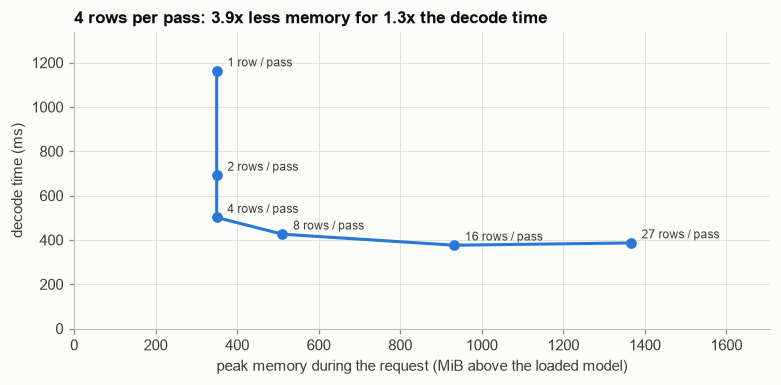

27 -> 4 rows per pass: 3.9x less memory for 1.30x the decode time; one row per pass: 3.0x
default budget: plan counts 853 MiB of KV copies, the pass peaks at 1366 MiB (1.6x: allocation steps, the rows themselves, activations)


In [15]:
d0, peak0 = sweep[0]["decode"], sweep[0]["peak"]
k = next(i for i, s in enumerate(sweep) if s["rows"] < 8)
fig, ax = plt.subplots(figsize=(7.2, 3.6))
ax.plot([s["peak"] for s in sweep], [s["decode"] for s in sweep], "-o", color=SERIES[0])
for s in sweep:
    ax.annotate(f"{s['rows']} row{'s' if s['rows'] > 1 else ''} / pass", (s["peak"], s["decode"]), textcoords="offset points", xytext=(7, 3),
                fontsize=8, color=INK_2)
ax.set_xlabel("peak memory during the request (MiB above the loaded model)")
ax.set_ylabel("decode time (ms)")
ax.set_ylim(0, max(s["decode"] for s in sweep) * 1.15)
ax.set_xlim(0, max(s["peak"] for s in sweep) * 1.25)
ax.set_title(f"{sweep[k]['rows']} rows per pass: {peak0 / sweep[k]['peak']:.1f}x less memory for {sweep[k]['decode'] / d0:.1f}x the decode time")
plt.tight_layout(); plt.show()
print(f"{sweep[0]['rows']} -> {sweep[k]['rows']} rows per pass: {peak0 / sweep[k]['peak']:.1f}x less memory for "
      f"{sweep[k]['decode'] / d0:.2f}x the decode time; one row per pass: {sweep[-1]['decode'] / d0:.1f}x")
print(f"default budget: plan counts {27 * p1.nbytes / 2**20:.0f} MiB of KV copies, the pass peaks at {peak0:.0f} MiB "
      f"({peak0 / (27 * p1.nbytes / 2**20):.1f}x: allocation steps, the rows themselves, activations)")

At first the trade is almost free. Sixteen rows per pass decode about as fast as 27, with a third less memory, and eight rows per pass cost only a little more time for well under half the memory. Below that it turns. The peak stops falling at about 350 MiB, which is the rest of the request (the prefills and the anchor round) and not the batch. The passes keep multiplying: at one row per pass, 30 forward passes and about three times the decode time.

The budget is an estimate, not a cap. At the default it counts 853 MiB of KV copies, and the pass peaks higher, because of the 256-token allocation steps from section 2, the rows themselves and the activations. Leave headroom when you size it for a big model.

The `forward passes` column comes from a counter, not a formula. Each backend increments `forward_passes` once per model call it actually makes: one per prefill chunk, one per scoring chunk (and, for the autoregressive baseline of post [01](01_why_parallel_decoding.ipynb), one per generated token). `Stats.forward_passes` is the counter's difference over a request, so a budget that splits the batch shows up in the stats without anyone having to predict it.

## 5. Projecting only what we read

The last layer of a language model projects every position onto the vocabulary. For the batched triage round that is a lot of logits nobody reads:

In [16]:
V_model = backend.model.args.vocab_size
width = max(map(len, rows))
n_queries = len(warm.calls[-1][1][2])
print(f"full projection: {len(rows)} rows x {width} positions x {V_model:,} tokens = {len(rows) * width * V_model / 1e6:.0f}M logits "
      f"({len(rows) * width * V_model * 2 / 2**20:.0f} MiB in fp16)")
print(f"read by the decoder: {n_queries} positions x {V_model:,} = {n_queries * V_model / 1e6:.1f}M logits")

full projection: 27 rows x 10 positions x 151,936 tokens = 41M logits (78 MiB in fp16)
read by the decoder: 46 positions x 151,936 = 7.0M logits


So the backends split the model into a *body* (tokens to hidden states) and a *head* (hidden states to logits), gather the queried positions, and project only those:

In [17]:
show_source("backends/mlx_backend.py", "if self._split is not None:", "self.forward_passes += 1")

# src/pcd/backends/mlx_backend.py
127              if self._split is not None:
128                  body, head = self._split
129                  hidden = body(batch, cache)
130                  logits = head(hidden[ridx_a, pidx_a])
131              else:
132                  logits = self.model(batch, cache=cache)[ridx_a, pidx_a]
133              self.forward_passes += 1


How much does it save? We time the batched round with the fast path and with a second backend that wraps the same loaded weights with `fast_path=False`, first with the default decoder and then with exact scoring, whose rows are longer (post [04](04_decoding.ipynb) §5):

In [18]:
slow = MLXBackend(backend.model, tok, fast_path=False, model_id="same weights, full projection")
fields = [cs.fields[n] for n in names]
fp = {}
for strategy in ["auto", "exact"]:
    opts = replace(engine.decode, strategy=strategy)
    fast_ms, (a, _, n_rows) = timed(lambda: decode_fields(backend, p1, fields, opts, wave=1), repeats=5)
    slow_ms, (b, _, _) = timed(lambda: decode_fields(slow, p1, fields, opts, wave=1), repeats=5)
    fp[strategy] = (n_rows, fast_ms, slow_ms, all(a[n].value == b[n].value for n in names),
                    max(abs(a[n].probability - b[n].probability) for n in names))
md_table(["strategy", "rows", "full projection (ms)", "fast path (ms)", "speed-up", "same decisions", "max change in probability"],
         [[s, r, f"{sl:.0f}", f"{f:.0f}", f"{sl / f:.2f}x", same, f"{dp:.1e}"] for s, (r, f, sl, same, dp) in fp.items()])
head_share = V_model * args.hidden_size / 1.5e9
print(f"the head is {V_model:,} x {args.hidden_size:,} = {V_model * args.hidden_size / 1e6:.0f}M weights, "
      f"{head_share:.0%} of a {MODELS['qwen2.5-1.5b'].params} model")

| strategy | rows | full projection (ms) | fast path (ms) | speed-up | same decisions | max change in probability |
|---|---|---|---|---|---|---|
| auto | 27 | 374 | 343 | 1.09x | True | 0.0e+00 |
| exact | 110 | 1522 | 1390 | 1.10x | True | 0.0e+00 |

the head is 151,936 x 1,536 = 233M weights, 16% of a 1.5B model


About 1.1×, for the default decoder and for exact scoring alike, with identical probabilities. That is roughly the head's share of the work. Its 233M weights are 16% of the model, and the full projection applies them to every position while the fast path applies them only to the queried ones. The rest of a scoring pass is the body, including every row's attention over the 1,155-token prefix, and the fast path does not touch it. A model whose vocabulary is large for its size gains more, as section 6 shows.

The split is not free to get wrong. Some architectures do more between the last hidden state and the logits than a matrix product, and a split that skips it would silently change every probability. So the backend never trusts a split it has not checked: on load, it runs the model both ways on a short input and keeps the fast path only if the logits agree.

In [19]:
show_source(MLXBackend._probe_fast_path)

# src/pcd/backends/mlx_backend.py
188      def _probe_fast_path(self):
189          model_type = getattr(getattr(self.model, "args", None), "model_type", "")
190          make = _HEAD_REGISTRY.get(model_type, _default_split)
191          try:
192              split = make(self.model)
193              if split is None:
194                  return None
195              body, head = split
196              # Same shapes as the model's own forward, so both sides use the same kernels:
197              # the check is about what the head computes, not about rounding.
198              x = mx.array([[1, 2, 3, 4, 5, 6, 7, 8]])
199              ref = self.model(x, cache=self._make_cache())[0, -1]
200              got = head(body(x, self._make_cache()))[0, -1]
201              mx.eval(ref, got)
202              ok = verify_close(np.array(ref.astype(mx.float32)), np.array(got.astype(mx.float32)))
203              return split if ok else None
204          except Exception:
205              return Non

Gemma 2 is the architecture that needs this. It soft-caps its logits, `cap · tanh(logits / cap)`, after the projection. The Gemma 2 weights are not on this machine, but the head does not depend on the weights, so we build a two-layer random Gemma 2 the way the test suite does (`tests/helpers.py`, cap 5.0):

In [20]:
sys.path.insert(0, str(ROOT / "tests"))
from helpers import byte_tokenizer, save_tiny
import mlx_lm

tiny_dir = save_tiny(tempfile.mkdtemp(), byte_tokenizer(), "gemma2")
tiny, tiny_tok = mlx_lm.load(tiny_dir)
cap = tiny.final_logit_softcapping
x = mx.array([tiny_tok.encode("Soft-capped logits need their own head.")])
ref = tiny(x)[0, -1].astype(mx.float32)
body, head = _default_split(tiny)
raw = head(body(x, None))[0, -1].astype(mx.float32)
body, head = _HEAD_REGISTRY["gemma2"](tiny)
capped = head(body(x, None))[0, -1].astype(mx.float32)
ref, raw, capped = (np.array(a, dtype=np.float64) for a in (ref, raw, capped))
lsm = lambda z: z - np.logaddexp.reduce(z)
print(f"cap {cap}: model logits in [{ref.min():.2f}, {ref.max():.2f}]; generic split's logits in [{raw.min():.2f}, {raw.max():.2f}]")
print(f"generic split:    passes the probe: {verify_close(ref, raw)}, TV distance to the model {tv(lsm(ref), lsm(raw)):.2f}")
print(f"registered split: passes the probe: {verify_close(ref, capped)}, TV distance to the model {tv(lsm(ref), lsm(capped)):.1e}")

registered = _HEAD_REGISTRY.pop("gemma2")
print("\nMLX backend without the registered head, fast path:", MLXBackend(tiny, tiny_tok).describe()["fast_path"])
register_head("gemma2", registered)
print("MLX backend with the registered head, fast path:   ", MLXBackend(tiny, tiny_tok).describe()["fast_path"])

cap 5.0: model logits in [-3.46, 4.81]; generic split's logits in [-4.26, 9.83]
generic split:    passes the probe: False, TV distance to the model 0.80
registered split: passes the probe: True, TV distance to the model 0.0e+00

MLX backend without the registered head, fast path: False
MLX backend with the registered head, fast path:    True


The generic split produces logits well outside the cap and a different distribution, the probe catches it, and the backend falls back to projecting everything. Correctness never depends on the fast path. The registered head (six lines in `mlx_backend.py`, and the example in `CONTRIBUTING.md`) applies the cap after the gather and passes the same probe. The PyTorch backend has no registry; for a model whose split fails it asks `transformers` for the queried positions only (`logits_to_keep`), which keeps the model's own post-processing.

## 6. Other architectures, same two primitives

Nothing in sections 1 to 5 was specific to Qwen2.5. To check that, we load four architectures with four different cache designs, one at a time, and for each look at what its prefix holds for the same triage prompt (rendered with its own chat template) and run the conformance suite of `pcd.testing`. Each check computes the same distribution two ways, such as a cached prefix extended versus the whole sequence prefilled at once, or a row in a batch versus alone. We run it twice: as the model ships, and with float32 activations.

In [21]:
del engine, fresh, slow, backend, p0, p1, layer, warm, cold, again, tiny
unload()


def inspect_model(alias):
    b = load(alias)
    c = Engine(b).compile(schema)
    ids = b.tokenizer.encode(c.prompt.render(ticket.strip()))
    full, half = b.prefill(ids), b.prefill(ids[: len(ids) // 2])
    slope = (full.nbytes - half.nbytes) / (len(ids) - len(ids) // 2)
    kinds = Counter(type(l).__name__ for l in full.state)
    shapes = {}
    for l in full.state:
        shapes.setdefault(type(l).__name__, " + ".join(str(tuple(a.shape)) for _, a in tree_flatten(l.state) if a is not None))
    meta = {type(l).__name__: l.meta_state for l in full.state}
    checks = check_backend(b)
    with float32(b.model):
        checks32 = check_backend(b, tol=1e-4)
    return dict(alias=alias, describe=b.describe(), tokens=len(ids), kinds=kinds, shapes=shapes, meta=meta,
                mib=full.nbytes / 2**20, per_token=slope, fixed=(full.nbytes - slope * len(ids)) / 2**20,
                checks=checks, checks32=checks32)


ARCHS = ["qwen2.5-1.5b", "gemma3-1b", "lfm2.5-1.2b", "qwen3.5-0.8b"]
info = {}
for alias in ARCHS:
    info[alias] = inspect_model(alias)
    if alias != ARCHS[-1]:
        unload(alias)                    # one model in memory at a time; qwen3.5 stays for the next cells

md_table(["model", "layers: cache type", "state per layer (batch 1)", "prompt tokens", "prefix", "per token", "fixed"],
         [[f"`{a}`", ", ".join(f"{n} {t}" for t, n in i["kinds"].items()), "<br>".join(f"{t}: {s}" for t, s in i["shapes"].items()),
           i["tokens"], f"{i['mib']:.1f} MiB", f"{i['per_token']:,.0f} B", f"{i['fixed']:.2f} MiB"] for a, i in info.items()])
print("gemma3-1b RotatingKVCache meta_state (keep, max_size, offset, idx):", info["gemma3-1b"]["meta"]["RotatingKVCache"])

| model | layers: cache type | state per layer (batch 1) | prompt tokens | prefix | per token | fixed |
|---|---|---|---|---|---|---|
| `qwen2.5-1.5b` | 28 KVCache | KVCache: (1, 2, 1146, 128) + (1, 2, 1146, 128) | 1146 | 31.3 MiB | 28,672 B | 0.00 MiB |
| `gemma3-1b` | 22 RotatingKVCache, 4 KVCache | RotatingKVCache: (1, 1, 1211, 256) + (1, 1, 1211, 256)<br>KVCache: (1, 1, 1211, 256) + (1, 1, 1211, 256) | 1211 | 30.7 MiB | 26,624 B | 0.00 MiB |
| `lfm2.5-1.2b` | 10 ArraysCache, 6 KVCache | ArraysCache: (1, 2, 2048)<br>KVCache: (1, 8, 1353, 64) + (1, 8, 1353, 64) | 1353 | 15.9 MiB | 12,288 B | 0.08 MiB |
| `qwen3.5-0.8b` | 18 ArraysCache, 6 KVCache | ArraysCache: (1, 3, 6144) + (1, 16, 128, 128)<br>KVCache: (1, 2, 1169, 256) + (1, 2, 1169, 256) | 1169 | 32.3 MiB | 12,288 B | 18.63 MiB |

gemma3-1b RotatingKVCache meta_state (keep, max_size, offset, idx): ('0', '512', '1211', '1211')


Four designs behind one interface:

- **Qwen2.5**: a `KVCache` in every layer. The prefix is keys and values and nothing else, 28,672 bytes per token.
- **Gemma 3**: 22 of its 26 layers attend over a sliding window of 512 tokens (`RotatingKVCache`). After a prefill in one call they still hold the whole 1,211-token prompt: mlx-lm trims a rotating cache only when the next block of tokens is written into it (every new token must still see a full window), and `meta_state` records where the window stands. `Prefix.nbytes` counts what is held, so for Gemma 3 the budget overestimates the per-row copies, which get trimmed to the window during the pass.
- **LFM2.5**: 10 short-convolution layers, each carrying only its last few inputs (0.08 MiB in total, whatever the prompt length), and 6 attention layers.
- **Qwen3.5**: 18 linear-attention layers (Gated DeltaNet), each carrying a 128×128 recurrent state per head in float32, and 6 attention layers. The recurrent part is a fixed 18.6 MiB, more than half of this prefix; the attention part grows by 12,288 bytes per token, less than half of Qwen2.5's.

All four go through the same `_clone`: each cache class stores its tensors in `state` with the batch on axis 0 and its bookkeeping in `meta_state`, and `from_state` rebuilds it. Does that make every copy exact? The conformance suite answers per model:

In [22]:
check_names = [c.name for c in info[ARCHS[0]]["checks"] if "TV" in c.detail]


def worst_tv(checks, name):
    c = next(c for c in checks if c.name == name)
    return float(c.detail.split("= ")[1].split(",")[0]), c.passed


rows_ = []
for name in check_names:
    rows_.append([name] + [f"{worst_tv(info[a]['checks'], name)[0]:.1e}" for a in ARCHS])
rows_.append(["**all checks pass (tol 0.1)**"] + [str(all(c.passed for c in info[a]["checks"])) for a in ARCHS])
rows_.append(["**worst TV in float32**"] + [f"{max(worst_tv(info[a]['checks32'], n)[0] for n in check_names):.1e}" for a in ARCHS])
rows_.append(["**all checks pass in float32 (tol 1e-4)**"] + [str(all(c.passed for c in info[a]["checks32"])) for a in ARCHS])
md_table(["check (max TV distance)"] + [f"`{a}`" for a in ARCHS], rows_)

| check (max TV distance) | `qwen2.5-1.5b` | `gemma3-1b` | `lfm2.5-1.2b` | `qwen3.5-0.8b` |
|---|---|---|---|---|
| prefix extension is exact | 7.5e-03 | 1.1e-02 | 5.7e-02 | 1.9e-02 |
| prefill does not modify its parent | 0.0e+00 | 0.0e+00 | 0.0e+00 | 0.0e+00 |
| batched rows match single rows | 5.1e-03 | 4.0e-03 | 2.4e-02 | 2.1e-02 |
| chunking is invisible | 5.1e-03 | 4.0e-03 | 2.4e-02 | 2.1e-02 |
| score does not modify the prefix | 0.0e+00 | 0.0e+00 | 0.0e+00 | 0.0e+00 |
| positions index into the row | 4.5e-03 | 8.4e-03 | 4.2e-02 | 3.2e-02 |
| **all checks pass (tol 0.1)** | True | True | True | True |
| **worst TV in float32** | 5.8e-06 | 3.1e-06 | 8.1e-06 | 5.0e-06 |
| **all checks pass in float32 (tol 1e-4)** | True | True | True | True |

Every check passes on every architecture. The two properties that must hold exactly do: extending a prefix leaves its parent untouched, and scoring leaves the prefix untouched (distance 0). The other checks compute the same distribution with two different shapes, so they show the rounding spread of section 3: about 1e-2 on the attention-only models, more on the hybrids, up to 5.7e-2 when LFM2.5 extends a prefix instead of prefilling it in one call. That last number is why `check_backend` defaults to a tolerance of 0.1. It is rounding, not the cache copies: in float32 every distance on every model drops below 1e-5, and all checks pass at a tolerance of 1e-4. A real bug, such as the padded continuation of section 3, lands near 1 (a median of 0.99).

One more thing the table of caches does not show. The fast path of section 5 is on for three of the four models:

In [23]:
print({a: info[a]["describe"]["fast_path"] for a in ARCHS})
q35 = load("qwen3.5-0.8b")
print(f"{type(q35.model).__name__} children: {list(q35.model.children())}; default split: {_default_split(q35.model)}")

{'qwen2.5-1.5b': True, 'gemma3-1b': True, 'lfm2.5-1.2b': True, 'qwen3.5-0.8b': False}
Model children: ['language_model']; default split: None


Qwen3.5 wraps its text model in `language_model`, so the generic split finds no `model.model` and gives up, and the backend quietly projects every position. That is the safe failure, and `register_head` is the fix: one line tells the backend where the body is, and the probe verifies it as usual.

In [24]:
register_head("qwen3_5", lambda model: _default_split(model.language_model))
q35_fast = MLXBackend(q35.model, q35.tokenizer, model_id="qwen3.5-0.8b + registered head")
print(q35_fast.describe())
runs = {}
for label, b in [("generic (no fast path)", q35), ("registered head", q35_fast)]:
    e = Engine(b)
    e.extract(ticket, schema)
    decode, r = [], None
    for _ in range(5):
        r = e.extract(ticket, schema)
        decode.append(r.stats.decode_ms)
    runs[label] = (float(np.median(decode)), r)
(d_slow, r_slow), (d_fast, r_fast) = runs.values()
V35, H35 = q35.model.language_model.args.vocab_size, q35.model.language_model.args.hidden_size
print(f"decode {d_slow:.0f} ms -> {d_fast:.0f} ms ({d_slow / d_fast:.2f}x); same decisions: {r_slow.values == r_fast.values}; "
      f"max change in probability {max(abs(r_slow.fields[k].probability - r_fast.fields[k].probability) for k in r_slow.values):.1e}")
print(f"the head is {V35:,} x {H35:,} = {V35 * H35 / 1e6:.0f}M weights, {V35 * H35 / 0.8e9:.0%} of a {MODELS['qwen3.5-0.8b'].params} model")
del q35_fast
unload()

{'backend': 'mlx', 'model': 'qwen3.5-0.8b + registered head', 'fast_path': True, 'model_type': 'qwen3_5'}
decode 304 ms -> 243 ms (1.25x); same decisions: True; max change in probability 2.8e-03
the head is 248,320 x 1,024 = 254M weights, 32% of a 0.8B model


With the head registered, Qwen3.5 decodes about 1.2× faster, more than Qwen2.5's 1.1×, because its head is a larger share of the model: a 248,320-token vocabulary on a 1,024-wide model is about a third of its weights. The decisions stay the same, and the probabilities move in the third decimal, the shape effect of section 3 again. This is a gap in the built-in backend worth fixing: out of the box, the generic split misses Qwen3.5's `language_model` wrapper, so the model silently runs without the fast path.

## 7. MLX and PyTorch on the same weights

The last question is whether the two backends agree with each other. `Qwen/Qwen2.5-0.5B-Instruct` is a bf16 checkpoint that both mlx-lm and `transformers` load as is. We run every preset on MLX, recording every `score` call, then load the same weights on PyTorch (`mps`), run the presets again, and replay MLX's exact calls, prefix by prefix, to compare the log-probabilities query by query. Then we do it all again in float32. One framework is in memory at a time.

In [25]:
REPO = "Qwen/Qwen2.5-0.5B-Instruct"


def run_presets(b):
    """Every preset through a fresh engine; returns the extractions and every score call with its result."""
    calls, method = [], type(b).score

    def score(prefix, rws, queries):
        result = method(b, prefix, rws, queries)
        calls.append((prefix.tokens, rws, queries, result))
        return result

    e = Engine(b)
    b.score = score
    try:
        outs = {name: e.extract(load_preset(name)["context"], load_preset(name)["schema"]) for name in PRESET_NAMES}
    finally:
        del b.score
    return outs, calls


def replay(b, calls):
    """Largest and median absolute probability difference between the recorded results and b's."""
    prefixes, diffs = {}, []
    for tokens, rws, queries, recorded in calls:
        if tokens not in prefixes:
            prefixes[tokens] = b.prefill(tokens)
        for x, y in zip(recorded, b.score(prefixes[tokens], rws, queries)):
            diffs.append(float(np.max(np.abs(np.exp(x) - np.exp(y)))))
    return max(diffs), float(np.median(diffs)), len(diffs)


mlx_b = load(REPO, "mlx")
print(mlx_b.describe())
mlx_runs = {"bf16": run_presets(mlx_b)}
mlx_checks = {"bf16": check_backend(mlx_b)}
with float32(mlx_b.model):
    mlx_runs["float32"] = run_presets(mlx_b)
    mlx_checks["float32"] = check_backend(mlx_b, tol=1e-4)
del mlx_b
unload()

torch_b = load(REPO, "torch")
print(torch_b.describe())
parity = {}
for precision in ["bf16", "float32"]:
    if precision == "float32":
        torch_b.model.float()
    outs, _ = run_presets(torch_b)
    parity[precision] = dict(outs=outs, replay=replay(torch_b, mlx_runs[precision][1]), checks=check_backend(torch_b, tol=0.1 if precision == "bf16" else 1e-4))
del torch_b
unload()

table, disagreements = [], []
for precision, pr in parity.items():
    m_outs = mlx_runs[precision][0]
    same = total = 0
    for name in PRESET_NAMES:
        a, t = m_outs[name], pr["outs"][name]
        for k in a.values:
            total += 1
            if a.values[k] == t.values[k]:
                same += 1
            elif precision == "bf16":
                pa, pt = dict(a.fields[k].top), dict(t.fields[k].top)
                disagreements.append([name, k, f"`{a.values[k]}`", f"`{t.values[k]}`",
                                      f"{pa.get(a.values[k], float('nan')):.2f} / {pa.get(t.values[k], float('nan')):.2f}",
                                      f"{pt.get(a.values[k], float('nan')):.2f} / {pt.get(t.values[k], float('nan')):.2f}"])
    worst = max(max(worst_tv(c, n)[0] for n in check_names) for c in (mlx_checks[precision], pr["checks"]))
    mx_dp, med_dp, n_q = pr["replay"]
    table.append([precision, f"{same}/{total}", n_q, f"{med_dp:.1e}", f"{mx_dp:.1e}", f"{worst:.1e}"])
md_table(["precision", "same decisions", "queries replayed", "median abs. prob. difference", "max abs. prob. difference", "worst conformance TV (either backend)"], table)
md_table(["preset", "field (bf16 disagreements)", "MLX picks", "PyTorch picks", "MLX: p(its pick) / p(PyTorch's)", "PyTorch: p(MLX's pick) / p(its)"], disagreements)

{'backend': 'mlx', 'model': 'Qwen/Qwen2.5-0.5B-Instruct', 'fast_path': True, 'model_type': 'qwen2'}
{'backend': 'torch', 'model': 'Qwen/Qwen2.5-0.5B-Instruct', 'device': 'mps:0', 'dtype': 'bfloat16', 'fast_path': True, 'model_type': 'qwen2'}


| precision | same decisions | queries replayed | median abs. prob. difference | max abs. prob. difference | worst conformance TV (either backend) |
|---|---|---|---|---|---|
| bf16 | 86/88 | 231 | 1.9e-03 | 7.5e-02 | 4.7e-02 |
| float32 | 88/88 | 231 | 1.8e-06 | 2.6e-04 | 4.6e-06 |

| preset | field (bf16 disagreements) | MLX picks | PyTorch picks | MLX: p(its pick) / p(PyTorch's) | PyTorch: p(MLX's pick) / p(its) |
|---|---|---|---|---|---|
| code_security | remediation_effort | `MAJOR_ARCHITECTURE_CHANGE` | `PARAMETRIZED_SQL_REFACTOR` | 0.52 / 0.41 | 0.47 / 0.47 |
| high_cardinality_255 | customs_category | `CAT_001_Meat_&_Edible_Offal` | `CAT_005_Live_Trees_&_Plants` | 0.09 / 0.09 | 0.08 / 0.10 |

In bf16 the two frameworks agree on 86 of 88 decisions, and the two they split on are close calls: PyTorch has the top two labels of `remediation_effort` level, and on the 255-label customs field both winners have about 10%. Query by query the probabilities differ by about 2e-3 at the median and by several hundredths on the least stable query, enough to tip a tie. bf16 keeps 8 significant bits, and MLX and PyTorch reach each result through different kernels, so this is the size of disagreement to expect.

In float32 the disagreements go away: 88 of 88 decisions, probabilities within a few millionths at the median and a few ten-thousandths at worst, and both backends pass the conformance suite at 1e-4. On the same weights the two backends compute the same thing, to the precision they are asked to compute it in.

## What we learned

- Two primitives are enough. Every stage of the engine is a `prefill` on a parent or a `score` of rows against a prefix, and the backend counts the forward passes it actually makes.
- A prefix is the framework's cache. Copies are free until written and then cost a full copy per row, so memory limits the batch. `kv_budget_bytes` trades peak memory for passes, and the real peak runs above the planner's estimate.
- Right padding is safe because rows are never continued; continuing a padded batch would change most next tokens. What remains is fp16 rounding that depends on the shape of the batch: up to ~1e-2 in total variation, no decision changed, gone in float32.
- The fast path is worth about the head's share of the work, and it is used only after a probe proves it. Gemma 2's soft-capping and Qwen3.5's wrapper are why the probe and `register_head` exist.
- Plain, sliding-window, linear-attention and convolution caches pass the same conformance suite, and the same weights give the same decisions on MLX and PyTorch in float32, and all but two near-ties in bf16.

Next: [06 · Waves, caches and the bill](06_engine_and_benchmarks.ipynb)